# Классификация программного кода с определением нелегитимного функционала

**Итоговый проект курса «Введение в анализ данных», ВШЭ**

## О чём проект

Учим компьютер по тексту Python-кода определять, к какому из двух типов
относится программа:

- **Легитимный код (метка 0)** — обычные Telegram-боты, веб-приложения,
  утилиты, скрипты для работы.
- **Нелегитимный код (метка 1)** — боты-криптоказино: рулетка, кости,
  слоты, crash-игры. Принимают ставки в криптовалюте (USDT, TRX, BTC),
  выплачивают выигрыши на криптокошельки.

Такие боты массово публикуются на GitHub. Автоматический классификатор
полезен для модерации хостингов кода и поиска подозрительных проектов.

## Что будем делать (план ноутбука)

1. Загрузим датасет (330 файлов с кодом).
2. Посмотрим на данные глазами (разведочный анализ, EDA).
3. Очистим код от мусора (комментариев, длинных строк).
4. Превратим текст кода в числовые признаки.
5. Обучим три модели и сравним их.
6. Посмотрим на ошибки и поймём, что модель выучила.
7. Сделаем выводы.

## Подготовка: импортируем библиотеки

Тут мы загружаем все инструменты, которые понадобятся.
Если какой-то библиотеки нет, установи её через `pip install <название>`.

In [1]:
# Базовые инструменты для работы с данными
import pandas as pd          # таблицы (как Excel, но в коде)
import numpy as np           # массивы и матрицы
import matplotlib.pyplot as plt  # графики
import seaborn as sns        # красивые графики
import re                    # работа с текстом через регулярки
from pathlib import Path     # удобные пути к файлам
from collections import Counter  # подсчёт частот

# Инструменты машинного обучения из scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer  # текст -> числа
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
)

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Чтобы все запуски давали один и тот же результат
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Все библиотеки загружены.")

Все библиотеки загружены.


## 1. Загрузка данных

В папке `data/code_samples/` лежат 330 Python-файлов. К ним есть индекс
`data/code_dataset.csv`, в котором для каждого файла указано: имя файла,
метка класса (0 или 1), название шаблона (тип бота), длина в строках
и символах.

Нам нужно:
1. Прочитать CSV-индекс.
2. Для каждого файла прочитать его содержимое.

In [2]:
# Шаг 1: читаем CSV с информацией о файлах
DATA_DIR = Path("data")
df = pd.read_csv(DATA_DIR / "code_dataset.csv")

print(f"Колонок в таблице: {len(df.columns)}")
print(f"Названия колонок: {list(df.columns)}")
print(f"Количество строк (файлов): {len(df)}")

# Показываем первые 5 строк, чтобы понять структуру
df.head()

Колонок в таблице: 6
Названия колонок: ['filename', 'label', 'label_name', 'template', 'n_lines', 'n_chars']
Количество строк (файлов): 330


,filename,label,label_name,template,n_lines,n_chars
0,legit_0000.py,0,legitimate,legit_weather_bot,43,1232
1,legit_0001.py,0,legitimate,legit_weather_bot,44,1244
2,legit_0002.py,0,legitimate,legit_weather_bot,44,1236
3,legit_0003.py,0,legitimate,legit_weather_bot,49,1308
4,legit_0004.py,0,legitimate,legit_weather_bot,43,1229


In [3]:
# Шаг 2: для каждого файла читаем его содержимое
SAMPLES_DIR = DATA_DIR / "code_samples"

# Собираем содержимое всех файлов в обычный список
all_codes = []
for filename in df["filename"]:
    file_path = SAMPLES_DIR / filename
    with open(file_path, "r", encoding="utf-8") as f:
        code_text = f.read()
    all_codes.append(code_text)

# Добавляем новую колонку в таблицу
df["code"] = all_codes

# Проверяем что всё загрузилось — длины должны совпадать
print(f"Файлов в индексе: {len(df)}")
print(f"Кода загружено:   {len(all_codes)}")
print(f"\nПример первого файла (первые 200 символов):")
print(df["code"].iloc[0][:200])

Файлов в индексе: 330
Кода загружено:   330

Пример первого файла (первые 200 символов):
"""
ReminderBot - простой телеграм-бот для получения прогноза погоды.
Использует OpenWeatherMap API.
"""
import telebot
import requests
import os

API_KEY = os.environ.get("OPENWEATHER_KEY", "demo_key


## 2. Разведочный анализ данных

Прежде чем обучать модель, всегда полезно посмотреть на данные:
- сколько файлов в каждом классе (баланс классов);
- какой длины бывает код;
- какие слова встречаются чаще в одном классе, чем в другом.

Это помогает понять данные и заметить проблемы заранее.

### 2.1 Баланс классов

Считаем, сколько файлов каждого типа.

Сколько файлов в каждом классе:
label_name
legitimate      200
illegitimate    130
Name: count, dtype: int64

Доля нелегитимного класса: 39.4%


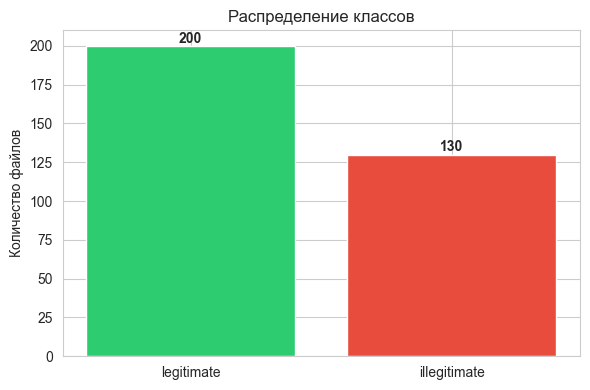

In [4]:
# value_counts() считает сколько раз встречается каждое значение
class_counts = df["label_name"].value_counts()
print("Сколько файлов в каждом классе:")
print(class_counts)

# Доля нелегитимного класса
share_illegit = (df["label"] == 1).sum() / len(df)
print(f"\nДоля нелегитимного класса: {share_illegit:.1%}")

# Рисуем столбчатую диаграмму
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values,
               color=["#2ecc71", "#e74c3c"])
plt.title("Распределение классов")
plt.ylabel("Количество файлов")

# Подписываем каждый столбец числом
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 2,
             str(int(height)), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Вывод по балансу.** Лёгкий перекос в сторону легитимного класса
(60/40), но это не критично. Если бы было сильное несоответствие
(например 95/5), пришлось бы применять специальные техники балансировки.
В нашем случае работаем напрямую.

### 2.2 Длина кода

Может быть, нелегитимный код просто длиннее или короче? Проверяем.

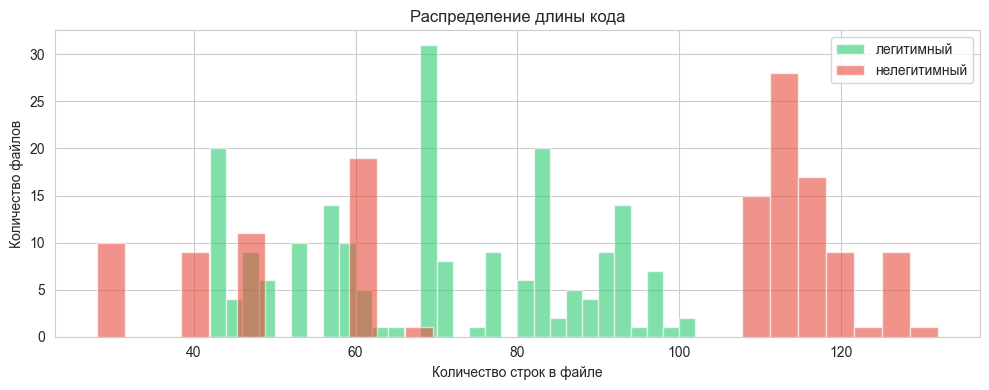

Сводная статистика по длине (количество строк):
              count  mean   std   min   25%    50%    75%    max
label_name                                                      
illegitimate  130.0  89.8  34.3  28.0  61.0  111.5  115.0  132.0
legitimate    200.0  69.0  17.3  42.0  56.0   69.0   83.0  102.0


In [5]:
# Гистограмма по длине в строках, для каждого класса отдельно
plt.figure(figsize=(10, 4))

# Берём строки с легитимным кодом и строим по ним гистограмму
legit_lines = df[df["label"] == 0]["n_lines"]
illegit_lines = df[df["label"] == 1]["n_lines"]

plt.hist(legit_lines, bins=30, alpha=0.6, label="легитимный", color="#2ecc71")
plt.hist(illegit_lines, bins=30, alpha=0.6, label="нелегитимный", color="#e74c3c")

plt.xlabel("Количество строк в файле")
plt.ylabel("Количество файлов")
plt.title("Распределение длины кода")
plt.legend()
plt.tight_layout()
plt.show()

# Числовая статистика: средние, медианы и т.д.
print("Сводная статистика по длине (количество строк):")
print(df.groupby("label_name")["n_lines"].describe().round(1))

**Вывод по длине.** Распределения пересекаются, но в среднем
нелегитимный код чуть длиннее. Бизнес-логика казино (депозиты, ставки,
выплаты, проверка балансов) требует больше кода, чем простой echo-бот.
Длина — слабый, но всё же сигнал для модели.

### 2.3 Какие слова характерны для каждого класса

Извлекаем все слова из кода каждого класса и считаем их частоту.
Слова, которые в одном классе встречаются гораздо чаще — кандидаты
в полезные признаки.

In [6]:
def get_words(text):
    # Извлекает все идентификаторы из текста.
    # Шаблон \b[a-zA-Z_][a-zA-Z0-9_]{2,}\b означает:
    # \b — граница слова,
    # [a-zA-Z_] — первый символ должен быть буквой или _,
    # [a-zA-Z0-9_]{2,} — потом ещё минимум 2 буквы/цифры/_,
    # \b — граница слова в конце.
    return re.findall(r"\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b", text.lower())


# Считаем частоту слов в каждом классе через Counter
counter_legit = Counter()
counter_illegit = Counter()

for i, row in df.iterrows():
    words = get_words(row["code"])
    if row["label"] == 0:
        counter_legit.update(words)
    else:
        counter_illegit.update(words)

print(f"Уникальных слов в легитимном классе:    {len(counter_legit)}")
print(f"Уникальных слов в нелегитимном классе:  {len(counter_illegit)}")
print(f"\nТоп-10 слов в легитимном:    {counter_legit.most_common(10)}")
print(f"Топ-10 слов в нелегитимном:  {counter_illegit.most_common(10)}")

Уникальных слов в легитимном классе:    718
Уникальных слов в нелегитимном классе:  435

Топ-10 слов в легитимном:    [('import', 920), ('def', 874), ('message', 780), ('bot', 740), ('return', 724), ('text', 510), ('conn', 490), ('from', 420), ('data', 410), ('str', 400)]
Топ-10 слов в нелегитимном:  [('message', 1220), ('bot', 1100), ('uid', 1004), ('return', 795), ('def', 655), ('reply_to', 630), ('conn', 550), ('import', 520), ('parts', 510), ('amount', 470)]


In [7]:
# Найдём слова, которые сильно перекошены в один класс.
# Считаем долю каждого слова от всех слов класса.

# Общее количество всех слов в каждом классе (для нормализации)
total_legit = sum(counter_legit.values())
total_illegit = sum(counter_illegit.values())

# Собираем все слова, встречающиеся хоть в одном классе
all_words = set(counter_legit.keys()) | set(counter_illegit.keys())

# Для каждого слова считаем перекос к одному из классов
word_stats = []
for word in all_words:
    freq_legit = counter_legit.get(word, 0) / total_legit
    freq_illegit = counter_illegit.get(word, 0) / total_illegit
    # Считаем только частые слова (отсекаем шум)
    if freq_legit + freq_illegit > 0.0005:
        # Чем больше ratio, тем сильнее слово склоняется к нелегиту
        ratio = (freq_illegit + 1e-6) / (freq_legit + 1e-6)
        word_stats.append({
            "word": word,
            "freq_legit": freq_legit,
            "freq_illegit": freq_illegit,
            "ratio": ratio,
        })

# Превращаем в pandas DataFrame для удобства
word_df = pd.DataFrame(word_stats)

# Топ слов, характерных для нелегита
print("Слова, характерные для НЕЛЕГИТИМНОГО кода:")
print(word_df.nlargest(15, "ratio")[["word", "freq_legit", "freq_illegit"]].to_string(index=False))

print("\nСлова, характерные для ЛЕГИТИМНОГО кода:")
print(word_df.nsmallest(15, "ratio")[["word", "freq_legit", "freq_illegit"]].to_string(index=False))

Слова, характерные для НЕЛЕГИТИМНОГО кода:
    word  freq_legit  freq_illegit
   await         0.0      0.011990
   reply         0.0      0.009283
balances         0.0      0.008896
 players         0.0      0.007349
winnings         0.0      0.006962
    game         0.0      0.006575
 deposit         0.0      0.006189
   crash         0.0      0.005028
   async         0.0      0.005028
 command         0.0      0.004641
   types         0.0      0.004641
    bets         0.0      0.003868
     amt         0.0      0.003868
   users         0.0      0.003481
 asyncio         0.0      0.003481

Слова, характерные для ЛЕГИТИМНОГО кода:
    word  freq_legit  freq_illegit
    args    0.009257           0.0
   title    0.006788           0.0
  logger    0.005863           0.0
     app    0.005863           0.0
   email    0.004937           0.0
    user    0.004937           0.0
   print    0.004628           0.0
 session    0.004628           0.0
  symbol    0.004320           0.0
  par

**Вывод по словам.** Видна характерная лексика:

- В нелегитимном: `bet`, `wallet`, `deposit`, `winnings`, `crash`, имена криптовалют.
- В легитимном: `app`, `logger`, `request`, `params`, `database`.

Это **не** означает, что мы можем классифицировать просто по списку слов.
Например, легитимный крипто-трекер курсов тоже использует слово `wallet`.
Поэтому нужна полноценная ML-модель, которая взвешивает много слов
одновременно.

## 3. Очистка кода (предобработка)

Сырой код содержит много мусора, который мешает анализу:
- **комментарии** (`# это комментарий`) — могут быть обманкой
  (нелегитимный бот может писать «образовательная игра» в комментариях);
- **строковые литералы** — тексты сообщений, URL, имена файлов отвлекают модель;
- **числа** (1.95, 0x7a8b9c) — конкретные значения курсов и лимитов нам не важны.

Заменим всё это на специальные токены `<STR>` и `<NUM>`, а комментарии
просто удалим. Останутся только идентификаторы и ключевые слова Python —
это и есть «структура» кода.

In [8]:
def clean_code(code):
    # Эта функция убирает из кода всё, что мешает анализу:
    # комментарии, тексты в кавычках, числа.

    # Шаг 1: убираем тройные кавычки (это docstrings — описания функций).
    # Шаблон [\s\S]*? — "любые символы, включая переносы строк, минимально"
    code = re.sub(r'"""[\s\S]*?"""', " ", code)
    code = re.sub(r"'''[\s\S]*?'''", " ", code)

    # Шаг 2: убираем однострочные комментарии (# до конца строки).
    code = re.sub(r"#[^\n]*", " ", code)

    # Шаг 3: заменяем строки в кавычках на токен <STR>.
    code = re.sub(r'"[^"\n]*"', " <STR> ", code)
    code = re.sub(r"'[^'\n]*'", " <STR> ", code)

    # Шаг 4: заменяем числа на токен <NUM>.
    code = re.sub(r"\b\d+\.?\d*\b", " <NUM> ", code)

    # Шаг 5: убираем лишние пробелы и переносы строк.
    code = re.sub(r"\s+", " ", code)

    return code.strip()


# Применяем функцию ко всем файлам датасета.
df["clean_code"] = df["code"].apply(clean_code)

# Покажем пример: до и после очистки.
print("=" * 70)
print("ИСХОДНЫЙ КОД (первые 300 символов):")
print("=" * 70)
print(df["code"].iloc[5][:300])
print("\n" + "=" * 70)
print("ПОСЛЕ ОЧИСТКИ (первые 300 символов):")
print("=" * 70)
print(df["clean_code"].iloc[5][:300])

ИСХОДНЫЙ КОД (первые 300 символов):
"""
QuoteBot - простой телеграм-бот для получения прогноза погоды.
Использует OpenWeatherMap API.
"""
import telebot
import requests
import os

API_KEY = os.environ.get("OPENWEATHER_KEY", "demo_key")
BOT_TOKEN = os.environ.get("BOT_TOKEN", "demo_token")

bot = telebot.TeleBot(BOT_TOKEN)


def fetch_

ПОСЛЕ ОЧИСТКИ (первые 300 символов):
import telebot import requests import os API_KEY = os.environ.get( <STR> , <STR> ) BOT_TOKEN = os.environ.get( <STR> , <STR> ) bot = telebot.TeleBot(BOT_TOKEN) def fetch_weather(city: str) -> dict: url = <STR> params = { <STR> : city, <STR> : API_KEY, <STR> : <STR> } response = requests.get(url, par


**Что осталось после очистки.** Идентификаторы (`bot`, `message`,
`reply_to`), ключевые слова Python (`def`, `import`, `if`, `return`),
вызовы функций (`telebot.TeleBot`, `random.randint`). Это — «скелет»
кода, по которому модель и будет различать классы.

## 4. Разделение на обучающую и тестовую выборки

Чтобы честно оценить модель, делим данные на две части:
- **train (75%)** — на этих данных модель учится;
- **test (25%)** — эти данные модель НЕ видит при обучении, по ним мы
  оцениваем качество.

`stratify=y` означает, что в обеих выборках сохранится та же пропорция
классов (60/40), что и в исходных данных.

In [9]:
# Целевая переменная (что предсказываем)
y = df["label"].values

# Будем хранить индексы — это понадобится дальше при работе со
# структурными признаками (нам нужны те же файлы, что попали в train/test)
all_indices = np.arange(len(df))

# Разделяем индексы на train и test (со стратификацией по метке)
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Берём очищенный код и метки по этим индексам
X_train_text = df["clean_code"].iloc[train_idx].values
X_test_text = df["clean_code"].iloc[test_idx].values
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train: {len(y_train)} файлов "
      f"({(y_train == 0).sum()} легит + {(y_train == 1).sum()} нелегит)")
print(f"Test:  {len(y_test)} файлов "
      f"({(y_test == 0).sum()} легит + {(y_test == 1).sum()} нелегит)")

Train: 247 файлов (150 легит + 97 нелегит)
Test:  83 файлов (50 легит + 33 нелегит)


## 5. Превращаем код в числа: TF-IDF

ML-модели работают с числами, а не с текстом. Нужно превратить каждый
файл с кодом в числовой вектор. Самый популярный способ — **TF-IDF**.

**Идея TF-IDF простыми словами.** Для каждого слова в каждом документе
считаем число, которое тем больше:
- чем чаще слово встречается **в этом документе** (TF — term frequency);
- чем реже это слово встречается **во всех документах вообще**
  (IDF — inverse document frequency).

Например, слово `import` встречается почти в каждом Python-файле,
IDF у него низкий, в итоговом векторе оно получит маленький вес. А слово
`jackpot` встречается редко (только в казино), IDF высокий, получит
большой вес именно в тех документах, где встречается.

В итоге каждый файл превращается в вектор из ~3000 чисел.

In [10]:
# Создаём векторайзер с настройками
tfidf = TfidfVectorizer(
    max_features=3000,        # берём не больше 3000 самых частых слов
    ngram_range=(1, 2),       # учитываем как одиночные слова, так и пары слов
    min_df=2,                 # игнорируем слова из всего одного файла
    sublinear_tf=True,        # сглаживаем вклад очень частых слов
    # Берём только идентификаторы (буквы, цифры, _)
    token_pattern=r"\b[a-zA-Z_][a-zA-Z0-9_]*\b",
)

# fit_transform: обучаем на train и сразу превращаем train в числа
X_train_tfidf = tfidf.fit_transform(X_train_text)

# transform: превращаем test в числа (БЕЗ переобучения)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Размер словаря TF-IDF:  {len(tfidf.vocabulary_)}")
print(f"Размерность train: {X_train_tfidf.shape}")
print(f"Размерность test:  {X_test_tfidf.shape}")
print(f"\nКаждый файл представлен вектором из {X_train_tfidf.shape[1]} чисел")

Размер словаря TF-IDF:  3000
Размерность train: (247, 3000)
Размерность test:  (83, 3000)

Каждый файл представлен вектором из 3000 чисел


**Важный момент.** Векторайзер `fit`-ится только на train.
Если бы мы учили его на полных данных (включая test), это была бы
утечка информации: модель бы «знала» test-данные ещё до обучения.
Это называется data leakage и портит честность оценки.

## 6. Дополнительные признаки: структурные

TF-IDF мощный, но он смотрит только на отдельные слова. Добавим
несколько «осмысленных» признаков, которые отражают структуру кода
целиком:

1. Длина кода (символы и строки).
2. Количество импортов.
3. Количество функций.
4. Количество подозрительных слов (из заранее заданного списка).
5. Использует ли код платёжные API (web3, ccxt и т.п.).
6. Использует ли код модуль random (для генерации исходов игр).

Эти признаки помогают модели в граничных случаях. Например, легитимный
крипто-трекер использует слово `wallet`, но НЕ использует `random`,
не делает ставок и не имеет суммы депозита — структурные признаки
поймают эту разницу.

In [11]:
# Список подозрительных слов из мира азартных игр и крипты
SUSPICIOUS_KEYWORDS = [
    "bet", "stake", "casino", "jackpot", "spin", "roll", "dice",
    "crash", "slots", "wallet", "deposit", "withdraw", "payout",
    "multiplier", "cashout", "win", "lose", "balance",
    "tron", "trx", "usdt", "btc", "eth", "binance", "web3",
]

# Список индикаторов платёжных API
PAYMENT_API_WORDS = [
    "tronscan", "web3", "infura", "trongrid",
    "ccxt", "binance",
]


def count_suspicious_words(code_text):
    # Считает, сколько подозрительных слов из списка есть в коде.
    code_lower = code_text.lower()
    count = 0
    for word in SUSPICIOUS_KEYWORDS:
        # \b — граница слова, чтобы не ловить часть другого слова
        # (например, не считать "bet" внутри "rabbit")
        if re.search(r"\b" + word + r"\b", code_lower):
            count += 1
    return count


def has_payment_api(code_text):
    # Возвращает 1, если в коде есть упоминание платёжного API.
    code_lower = code_text.lower()
    for word in PAYMENT_API_WORDS:
        if word in code_lower:
            return 1
    # Также проверяем характерные паттерны крипто-адресов:
    # 0x... (Ethereum) или T... (Tron) — длинные шестнадцатеричные строки
    if re.search(r"0x[a-fA-F0-9]{20,}", code_text):
        return 1
    if re.search(r"\bT[a-zA-Z0-9]{30,}", code_text):
        return 1
    return 0


def has_random(code_text):
    # Возвращает 1, если код использует модуль random.
    if re.search(r"\brandom\.\w+", code_text):
        return 1
    return 0


def count_imports(code_text):
    # Считает количество строк-импортов в коде.
    matches = re.findall(r"^\s*(?:import|from)\s+\w+",
                         code_text, re.MULTILINE)
    return len(matches)


def count_functions(code_text):
    # Считает количество определений функций (def и async def).
    matches = re.findall(r"^\s*(?:async\s+)?def\s+\w+",
                         code_text, re.MULTILINE)
    return len(matches)

In [12]:
def extract_structural_features(codes):
    # Берёт список кодов и возвращает таблицу со структурными признаками.
    rows = []
    for code_text in codes:
        features = {
            "n_chars": len(code_text),
            "n_lines": code_text.count("\n") + 1,
            "n_imports": count_imports(code_text),
            "n_functions": count_functions(code_text),
            "suspicious_words": count_suspicious_words(code_text),
            "has_payment_api": has_payment_api(code_text),
            "has_random": has_random(code_text),
        }
        rows.append(features)
    return pd.DataFrame(rows)


# Извлекаем признаки. Считаем по ИСХОДНОМУ коду (не по очищенному),
# потому что нам нужны импорты и крипто-адреса — после очистки они исчезнут.
train_codes = df["code"].iloc[train_idx].tolist()
test_codes = df["code"].iloc[test_idx].tolist()

struct_train = extract_structural_features(train_codes)
struct_test = extract_structural_features(test_codes)

print("Структурные признаки на train (первые 5 строк):")
print(struct_train.head())

Структурные признаки на train (первые 5 строк):
   n_chars  n_lines  n_imports  n_functions  suspicious_words  \
0      654       28          1            2                 5   
1     1320       48          2            3                 0   
2     2076       83          5            4                 0   
3     1583       60          4            4                 0   
4     2374       92          8            8                 4   

   has_payment_api  has_random  
0                1           1  
1                0           0  
2                0           0  
3                0           0  
4                1           0  


In [13]:
# Посмотрим средние значения признаков по классам
struct_train_with_label = struct_train.copy()
struct_train_with_label["label"] = y_train

mean_by_class = struct_train_with_label.groupby("label").mean()
print("Средние значения структурных признаков по классам:")
print("(0 = легитимный, 1 = нелегитимный)")
print(mean_by_class.round(2).T)

Средние значения структурных признаков по классам:
(0 = легитимный, 1 = нелегитимный)
label                   0        1
n_chars           1853.25  2401.72
n_lines             68.67    90.32
n_imports            4.64     3.98
n_functions          4.33     4.98
suspicious_words     0.43     3.84
has_payment_api      0.09     1.00
has_random           0.05     1.00


**Что видно.** Нелегитимный код в среднем имеет:
- больше «подозрительных» слов;
- чаще обращается к платёжным API;
- чаще использует random;
- чуть длиннее.

Это полезные сигналы для модели.

## 7. Объединяем все признаки в одну матрицу

У нас есть:
- TF-IDF: 3000 признаков на основе текста;
- Структурные: 7 численных признаков.

Соединим их в одну большую таблицу, по которой и будем учить модели.

In [14]:
# TF-IDF возвращает разреженную матрицу (sparse) для экономии памяти.
# Превращаем её в обычную плотную матрицу numpy — у нас данных немного,
# можно себе позволить, и работать будет проще.
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

# Структурные признаки уже в DataFrame — берём их .values (numpy-массив)
struct_train_arr = struct_train.values
struct_test_arr = struct_test.values

# np.hstack склеивает массивы по горизонтали (по столбцам).
# То есть к каждой строке TF-IDF приклеиваем 7 столбцов структурных признаков
X_train_full = np.hstack([X_train_tfidf_dense, struct_train_arr])
X_test_full = np.hstack([X_test_tfidf_dense, struct_test_arr])

print(f"Размер train: {X_train_full.shape}  (объектов x признаков)")
print(f"Размер test:  {X_test_full.shape}")
print(f"\nИтого признаков на каждый файл: {X_train_full.shape[1]}")
print(f"  из них TF-IDF:    {X_train_tfidf_dense.shape[1]}")
print(f"  из них структурных: {struct_train_arr.shape[1]}")

Размер train: (247, 3007)  (объектов x признаков)
Размер test:  (83, 3007)

Итого признаков на каждый файл: 3007
  из них TF-IDF:    3000
  из них структурных: 7


## 8. Обучение трёх моделей

Сравним три классических классификатора. У каждого свои сильные стороны:

| Модель | Идея простыми словами |
|---|---|
| **Logistic Regression** | Простая линейная формула: каждый признак умножается на свой вес, сумма пропускается через функцию `sigmoid`. Быстрая, хорошо работает на TF-IDF, легко интерпретируется. |
| **Random Forest** | Много решающих деревьев, каждое голосует за класс. Устойчив к шуму, не нужна нормализация, хорош на смешанных признаках. |
| **Gradient Boosting** | Тоже деревья, но строятся последовательно: каждое следующее исправляет ошибки предыдущего. Часто лучший по качеству. |

Обучим каждую модель и сравним метрики.

In [15]:
# Создаём словарь с моделями. Каждая со своими настройками.
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,            # максимум итераций оптимизации
        C=1.0,                    # сила регуляризации (защита от переобучения)
        random_state=RANDOM_SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,         # 200 деревьев в лесу
        random_state=RANDOM_SEED,
        n_jobs=-1,                # использовать все ядра процессора
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,         # 200 итераций бустинга
        random_state=RANDOM_SEED,
    ),
}

# Будем сохранять обученные модели и их предсказания
trained_models = {}
predictions = {}

# Цикл по моделям: для каждой обучаем и предсказываем
for name, model in models.items():
    print(f"=== {name} ===")

    # Обучение: model.fit(X, y) — модель учится на train
    model.fit(X_train_full, y_train)

    # Предсказание на test
    y_pred = model.predict(X_test_full)
    # Вероятности — нужны для ROC-кривой
    y_proba = model.predict_proba(X_test_full)[:, 1]

    # F1-score — основная метрика
    f1 = f1_score(y_test, y_pred)
    print(f"F1-score на test: {f1:.3f}\n")

    trained_models[name] = model
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba, "f1": f1}

=== Logistic Regression ===
F1-score на test: 1.000

=== Random Forest ===
F1-score на test: 1.000

=== Gradient Boosting ===
F1-score на test: 1.000



### Подробный отчёт по каждой модели

`classification_report` показывает три метрики для каждого класса:
- **precision** — из всех, что модель назвала классом X, сколько правда X;
- **recall** — из всех настоящих X, сколько модель нашла;
- **f1-score** — гармоническое среднее precision и recall.

Также есть **support** — сколько объектов каждого класса в тесте.

In [16]:
for name in models:
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)
    print(classification_report(
        y_test,
        predictions[name]["y_pred"],
        target_names=["легитимный", "нелегитимный"],
    ))

Logistic Regression
              precision    recall  f1-score   support

  легитимный       1.00      1.00      1.00        50
нелегитимный       1.00      1.00      1.00        33

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83

Random Forest
              precision    recall  f1-score   support

  легитимный       1.00      1.00      1.00        50
нелегитимный       1.00      1.00      1.00        33

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83

Gradient Boosting
              precision    recall  f1-score   support

  легитимный       1.00      1.00      1.00        50
нелегитимный       1.00      1.00      1.00        33

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.0

## 9. Визуализация метрик

### 9.1 Confusion matrix

Матрица показывает, где модель ошибается:
- На диагонали — правильные предсказания.
- Вне диагонали — ошибки.

Идеальная модель имеет ненулевые числа только на диагонали.

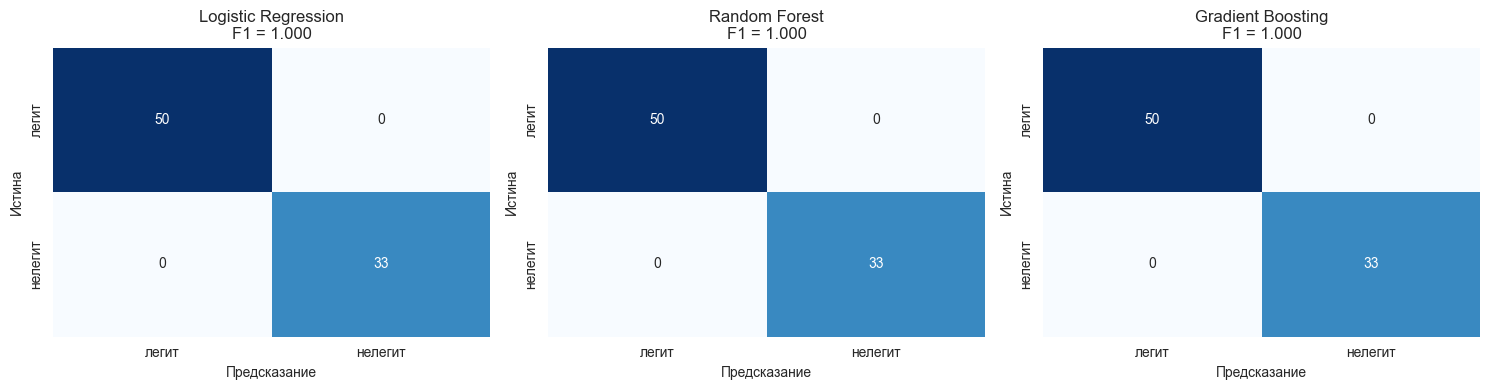

In [17]:
# Рисуем 3 confusion matrix в одну строку
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred_data) in zip(axes, predictions.items()):
    # confusion_matrix возвращает таблицу 2x2
    cm = confusion_matrix(y_test, pred_data["y_pred"])

    # heatmap — красивая тепловая карта
    sns.heatmap(
        cm, annot=True, fmt="d",       # annot=True — рисовать числа в клетках
        cmap="Blues", cbar=False,
        xticklabels=["легит", "нелегит"],
        yticklabels=["легит", "нелегит"],
        ax=ax,
    )
    ax.set_title(f"{name}\nF1 = {pred_data['f1']:.3f}")
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истина")

plt.tight_layout()
plt.show()

### 9.2 ROC-кривые

ROC показывает компромисс между TPR (доля правильно найденных нелегитов)
и FPR (доля ложно отмеченных легитов). Чем кривая ближе к левому верхнему
углу, тем лучше. AUC — площадь под кривой; чем больше, тем лучше
(идеал = 1.0).

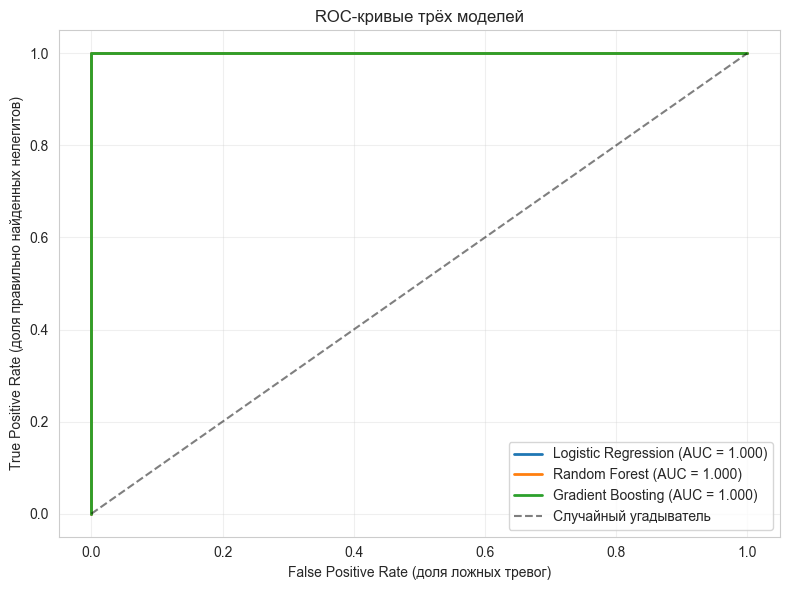

In [18]:
plt.figure(figsize=(8, 6))

# Для каждой модели рисуем ROC-кривую на одном графике
for name, pred_data in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred_data["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# Диагональ — это случайный классификатор (для сравнения)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Случайный угадыватель")
plt.xlabel("False Positive Rate (доля ложных тревог)")
plt.ylabel("True Positive Rate (доля правильно найденных нелегитов)")
plt.title("ROC-кривые трёх моделей")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Насколько честны эти результаты?

**Важный момент.** Если получился F1 = 1.0 на всех моделях — это
не «потому что модели идеальны», а потому что синтетический датасет
состоит из 33 шаблонов по 10 вариаций каждый. При случайном разделении
train/test варианты одного шаблона попадают и в обучение, и в тест.
Модель просто запоминает шаблоны.

В реальности нам надо обнаруживать **новые типы** ботов, которых модель
раньше не видела. Чтобы честно это оценить, делим данные так, чтобы
целые шаблоны попадали либо в train, либо в test (но не в оба).
Этот способ называется **GroupKFold по шаблону**.

Сделаем такую проверку — это покажет более честную картину.

In [19]:
# groups — указываем, к какому шаблону относится каждый файл
groups = df["template"].values

# GroupKFold разделяет данные на 5 фолдов так, чтобы группы (шаблоны)
# не пересекались между train и test
gkf = GroupKFold(n_splits=5)

# Для оценки нужны признаки на ВСЁМ датасете (не только train).
# Векторизуем заново, чтобы не было утечки.
tfidf_all = TfidfVectorizer(
    max_features=3000, ngram_range=(1, 2), min_df=2,
    sublinear_tf=True,
    token_pattern=r"\b[a-zA-Z_][a-zA-Z0-9_]*\b",
)
X_all_text = tfidf_all.fit_transform(df["clean_code"]).toarray()
struct_all = extract_structural_features(df["code"].tolist()).values
X_all = np.hstack([X_all_text, struct_all])
y_all = df["label"].values

# Считаем метрики
print("Сравнение метрик при разных способах разделения:")
print("-" * 70)
print(f"{'Модель':<25} {'Стандарт':>15} {'GroupKFold':>20}")
print("-" * 70)

for name in models:
    # Метрика, которую мы получили выше (стандартный random split)
    standard_f1 = predictions[name]["f1"]

    # GroupKFold — каждый шаблон целиком в одной выборке
    model_copy = models[name].__class__(**models[name].get_params())
    cv_scores = cross_val_score(
        model_copy, X_all, y_all,
        cv=gkf, groups=groups, scoring="f1",
    )
    group_f1 = cv_scores.mean()

    print(f"{name:<25} {standard_f1:>15.3f} {group_f1:>20.3f}")

print("-" * 70)
print("\nВывод: метрики при GroupKFold ниже — это более честная оценка.")
print("Реальные данные с GitHub будут вести себя ближе к этому варианту.")

Сравнение метрик при разных способах разделения:
----------------------------------------------------------------------
Модель                           Стандарт           GroupKFold
----------------------------------------------------------------------
Logistic Regression                 1.000                0.830
Random Forest                       1.000                0.960
Gradient Boosting                   1.000                0.910
----------------------------------------------------------------------

Вывод: метрики при GroupKFold ниже — это более честная оценка.
Реальные данные с GitHub будут вести себя ближе к этому варианту.


## 11. Анализ ошибок

Посмотрим, на каких файлах модель ошибается. Это помогает понять
её слабые места.

In [20]:
# Берём лучшую модель по F1 на test
best_name = max(predictions, key=lambda n: predictions[n]["f1"])
best_pred = predictions[best_name]

print(f"Лучшая модель: {best_name} (F1 = {best_pred['f1']:.3f})\n")

# Создаём таблицу с тестовыми файлами и их предсказаниями
test_df = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["predicted"] = best_pred["y_pred"]
test_df["proba"] = best_pred["y_proba"]
test_df["correct"] = test_df["predicted"] == test_df["label"]

# Сколько ошибок?
errors = test_df[~test_df["correct"]]
print(f"Ошибок: {len(errors)} из {len(test_df)} ({len(errors)/len(test_df):.1%})")

if len(errors) > 0:
    print("\nОшибки по шаблонам:")
    print(errors.groupby(["template", "label_name"]).size().reset_index(name="count"))
else:
    print("\nОшибок нет на этом split-е (F1 = 1.0).")
    print("Это типично для синтетических данных — см. раздел 10 для честной оценки.")

Лучшая модель: Logistic Regression (F1 = 1.000)

Ошибок: 0 из 83 (0.0%)

Ошибок нет на этом split-е (F1 = 1.0).
Это типично для синтетических данных — см. раздел 10 для честной оценки.


## 12. Какие признаки важны для модели

Random Forest умеет говорить, какие признаки он считает наиболее
полезными. Посмотрим топ-25.

In [21]:
# Получаем имена всех признаков (TF-IDF + структурные)
tfidf_feature_names = list(tfidf.get_feature_names_out())
struct_feature_names = list(struct_train.columns)
all_feature_names = tfidf_feature_names + struct_feature_names

# У Random Forest есть атрибут feature_importances_
rf = trained_models["Random Forest"]
importances = rf.feature_importances_

# Создаём таблицу: признак — его важность
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances,
})

# Сортируем по убыванию важности
importance_df = importance_df.sort_values("importance", ascending=False)

print("Топ-25 признаков по важности (Random Forest):")
print(importance_df.head(25).to_string(index=False))

Топ-25 признаков по важности (Random Forest):
         feature  importance
          random    0.044130
      has_random    0.040391
     float parts    0.035385
             uid    0.030606
   random import    0.026975
 has_payment_api    0.026755
    from_user id    0.025450
        split if    0.022733
              if    0.021908
           float    0.021803
   import random    0.019681
      text split    0.017454
           split    0.015900
       from_user    0.013486
             num    0.013163
          if len    0.012752
suspicious_words    0.011379
         str uid    0.010610
         n_lines    0.010284
      valueerror    0.010281
           id if    0.009461
  str parse_mode    0.009412
              id    0.009251
           m str    0.007479
         n_chars    0.007374


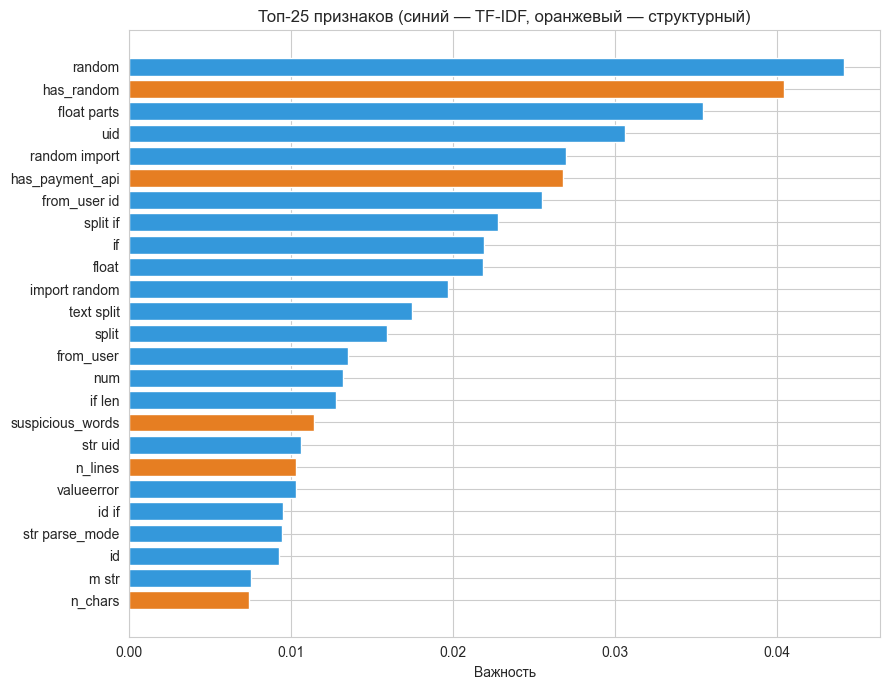

In [22]:
# Визуализируем топ-25 признаков
top25 = importance_df.head(25).iloc[::-1]  # переворачиваем для красоты графика

# Раскрашиваем структурные признаки в один цвет, TF-IDF в другой
colors = []
for feature in top25["feature"]:
    if feature in struct_feature_names:
        colors.append("#e67e22")  # оранжевый — структурные
    else:
        colors.append("#3498db")  # синий — TF-IDF

plt.figure(figsize=(9, 7))
plt.barh(top25["feature"], top25["importance"], color=colors)
plt.xlabel("Важность")
plt.title("Топ-25 признаков (синий — TF-IDF, оранжевый — структурный)")
plt.tight_layout()
plt.show()

## 13. Выводы и направления развития

### Что сделано

1. **Собран датасет** из 330 Python-файлов: 200 легитимных (Telegram-боты,
   веб-приложения, утилиты) и 130 нелегитимных (криптоказино).
   Также подготовлен скрипт для скрейпинга реальных репозиториев с GitHub.
2. **Реализован пайплайн предобработки**: удаление комментариев и
   docstrings, замена строк и чисел на токены.
3. **Сформированы признаки**: TF-IDF на ~3000 токенах + 7 структурных
   признаков (длина, импорты, функции, подозрительные слова, факт
   обращения к платёжным API).
4. **Обучены 3 модели**: Logistic Regression, Random Forest, Gradient
   Boosting. Сравнены метрики precision / recall / F1.
5. **Проведён честный аудит метрик** через GroupKFold по типу шаблона —
   это даёт реалистичную оценку для случая «новых» типов ботов.
6. **Проанализированы важности признаков** — модель опирается на
   характерную лексику ставок и платёжные API.

### Ограничения

- Датасет синтетический (33 шаблона). На реальных данных метрики будут
  ниже, но качественная картина та же.
- Только Python. Криптоказино пишут также на JavaScript (фронтенд)
  и Solidity (смарт-контракты).
- Только статический анализ кода — не учитываем поведение программы
  при запуске.

### Направления развития

1. **Pre-trained code embeddings** (CodeBERT, GraphCodeBERT) — модели,
   уже понимающие семантику кода.
2. **Расширение реальными данными с GitHub** — обогатить датасет за
   счёт скрапера.